In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:15pt;}
div.output {font-size:15pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:15pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>
"""))

In [45]:
import numpy as np
import pandas as pd
import sys
from tensorflow.keras import utils #utils.to_categorical 원핫인코딩
from tensorflow.keras.models import Sequential #모델 생성
from tensorflow.keras.layers import Dense, Input
import matplotlib.pyplot as plt #학습 과정 그래프
from sklearn.metrics import confusion_matrix #혼동행렬
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split # 데이터 분리

# 이진분류
1. 데이터 셋 생성 & 전처리
     엑셀 -> 데이터프레임 -> ?처리(df.replace('?',np.nan) -> 결측치 처리
     -> X, y 분리 -> X변수 스케일조정 -> train_test_split함수로 학습셋과 테스트셋분리
2. 모델 생성(입력13, 출력1) & 학습과정 설정 & 학습
3. 모델 평가(그래프, 평가, 교차표)
4. 모델 사용(저장, 예측)

# 컬럼명 의미 및 설명
- cp 흉통의 유형 (Chest Pain type)
- 0: 전형적 협심증 / 1: 비전형적 협심증 / 2: 비심장성 흉통 / 3: 무증상
- treshtbps 안정 시 수축기 혈압 (Resting Blood Pressure in mm Hg)
- chol 혈청 콜레스테롤 수치 (Serum Cholesterol in mg/dl)
- fbs 공복혈당 120mg/dl 이상 여부 (Fasting Blood Sugar) - 1: Yes, 0: No
- restecg 안정 시 심전도 결과 (Resting Electrocardiographic Results)- 
- 0: 정상 / 1: ST-T 이상 / 2: 좌심실 비대 가능성
- thalach 최대 심박수 (Maximum Heart Rate Achieved)
- exang 운동 중 협심증 여부 (Exercise Induced Angina) - 1: 있음, 0: 없음
- oldpeak 운동 후 ST 감소 정도 (ST Depression induced by exercise relative to rest)
- slope ST segment의 기울기 (Slope of the peak exercise ST segment)
- 1: 수평 / 2: 상승 / 3: 하강
- ca 형광투시검사에서 관찰된 주요 혈관 수 (Number of major vessels colored by fluoroscopy)
- hsl (일반적으로 thal로 표기됨) 지혈소 상태 (Thalassemia)
- 3: 정상 / 6: 고정결함 / 7: 가역적 결함
- heartDisease 심장병 여부 (Target Variable)
- 1: 심장병 있음 / 0: 없음

## 1. 데이터 셋 생성 & 전처리
     엑셀 -> 데이터프레임 -> ?처리(df.replace('?',np.nan) ->결측치 처리
     -> X, y분리 -> X변수 스케일조정 -> train_test_split함수로 학습셋과 테스트셋분리

In [18]:
dataset = pd.read_excel('data/heart-disease.xlsx')
dataset.isin(['?']).any() #물음표가 있는 열 여부

age             False
sex             False
cp              False
treshtbps       False
chol             True
fbs             False
restecg         False
thalach         False
exang           False
oldpeak         False
slope           False
ca               True
hsl              True
heartDisease    False
dtype: bool

In [32]:
#결측치 처리
df = dataset.replace('?',np.nan)
df.fillna(value=df.median(), inplace=True)

In [49]:
X = df.iloc[:,:-1].values
y = df.iloc[:,-1:].values
X.shape, y.shape

((303, 13), (303, 1))

In [50]:
#Scale조정
scaler = MinMaxScaler()
scaled_X = scaler.fit_transform(X)

In [55]:
# X, y분리
X_train, X_test, y_train, y_test = train_test_split(scaled_X, y,
                                                   test_size=0.3, #테스트셋비율
                                                    random_state=7,
                                                    #stratify=y #층화추출
                                                   )
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((212, 13), (91, 13), (212, 1), (91, 1))

# 2. 모델 생성(입력13, 출력1) & 학습과정 설정 & 학습

In [56]:
model = Sequential()
model.add(Input(shape=(13,))) 
model.add(Dense(units=32, activation='relu'))
model.add(Dense(units=16, activation='relu'))
model.add(Dense(units=1, activation='sigmoid'))
model.summary()

Model: "sequential_9"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_8 (Dense)             (None, 32)                448       
                                                                 
 dense_9 (Dense)             (None, 16)                528       
                                                                 
 dense_10 (Dense)            (None, 1)                 17        
                                                                 
Total params: 993
Trainable params: 993
Non-trainable params: 0
_________________________________________________________________


In [59]:
from tensorflow.keras import metrics
from tensorflow.keras.optimizers import Adam

model.compile(loss='binary_crossentropy',
             optimizer=Adam(learning_rate=0.01),
             metrics=['accuracy', #정확도
                      metrics.Recall(), #재현율(실제값중심)
                      metrics.Precision()]) #정밀도(예측값)

In [60]:
hist = model.fit(X_train, y_train, #훈련데이터
                 epochs=150, #학습횟수
                 validation_split=0.2 #검증데이터를 훈련데이터의 20%로 사용
                )

Epoch 1/150
6/6 [==============================] - 1s 57ms/step - loss: 0.6518 - accuracy: 0.5976 - recall: 0.0423 - precision: 1.0000 - val_loss: 0.6002 - val_accuracy: 0.7674 - val_recall: 0.6111 - val_precision: 0.7857
Epoch 2/150
6/6 [==============================] - 0s 8ms/step - loss: 0.5451 - accuracy: 0.8047 - recall: 0.5634 - precision: 0.9524 - val_loss: 0.5463 - val_accuracy: 0.7674 - val_recall: 0.7222 - val_precision: 0.7222
Epoch 3/150
6/6 [==============================] - 0s 9ms/step - loss: 0.4753 - accuracy: 0.8343 - recall: 0.7042 - precision: 0.8772 - val_loss: 0.5185 - val_accuracy: 0.8140 - val_recall: 0.8889 - val_precision: 0.7273
Epoch 4/150
6/6 [==============================] - 0s 9ms/step - loss: 0.4128 - accuracy: 0.8343 - recall: 0.7887 - precision: 0.8116 - val_loss: 0.4996 - val_accuracy: 0.8140 - val_recall: 0.8889 - val_precision: 0.7273
Epoch 5/150
6/6 [==============================] - 0s 10ms/step - loss: 0.3835 - accuracy: 0.8521 - recall: 0.7465 

Epoch 38/150
6/6 [==============================] - 0s 8ms/step - loss: 0.1351 - accuracy: 0.9586 - recall: 0.9155 - precision: 0.9848 - val_loss: 0.8671 - val_accuracy: 0.7674 - val_recall: 0.8889 - val_precision: 0.6667
Epoch 39/150
6/6 [==============================] - 0s 8ms/step - loss: 0.1385 - accuracy: 0.9467 - recall: 0.9577 - precision: 0.9189 - val_loss: 0.8008 - val_accuracy: 0.7442 - val_recall: 0.8333 - val_precision: 0.6522
Epoch 40/150
6/6 [==============================] - 0s 8ms/step - loss: 0.1386 - accuracy: 0.9527 - recall: 0.8873 - precision: 1.0000 - val_loss: 0.8717 - val_accuracy: 0.7442 - val_recall: 0.8889 - val_precision: 0.6400
Epoch 41/150
6/6 [==============================] - 0s 7ms/step - loss: 0.1203 - accuracy: 0.9527 - recall: 0.9155 - precision: 0.9701 - val_loss: 0.8507 - val_accuracy: 0.7674 - val_recall: 0.8889 - val_precision: 0.6667
Epoch 42/150
6/6 [==============================] - 0s 9ms/step - loss: 0.1068 - accuracy: 0.9763 - recall: 0.97

Epoch 75/150
6/6 [==============================] - 0s 8ms/step - loss: 0.0446 - accuracy: 0.9822 - recall: 0.9577 - precision: 1.0000 - val_loss: 1.0702 - val_accuracy: 0.7442 - val_recall: 0.8889 - val_precision: 0.6400
Epoch 76/150
6/6 [==============================] - 0s 8ms/step - loss: 0.0450 - accuracy: 0.9882 - recall: 0.9859 - precision: 0.9859 - val_loss: 1.1101 - val_accuracy: 0.7674 - val_recall: 0.9444 - val_precision: 0.6538
Epoch 77/150
6/6 [==============================] - 0s 10ms/step - loss: 0.0335 - accuracy: 0.9941 - recall: 0.9859 - precision: 1.0000 - val_loss: 1.0374 - val_accuracy: 0.7674 - val_recall: 0.8889 - val_precision: 0.6667
Epoch 78/150
6/6 [==============================] - 0s 9ms/step - loss: 0.0504 - accuracy: 0.9763 - recall: 0.9437 - precision: 1.0000 - val_loss: 1.2052 - val_accuracy: 0.7674 - val_recall: 1.0000 - val_precision: 0.6429
Epoch 79/150
6/6 [==============================] - 0s 10ms/step - loss: 0.0488 - accuracy: 0.9882 - recall: 1.

Epoch 112/150
6/6 [==============================] - 0s 8ms/step - loss: 0.0104 - accuracy: 1.0000 - recall: 1.0000 - precision: 1.0000 - val_loss: 1.2294 - val_accuracy: 0.7674 - val_recall: 0.9444 - val_precision: 0.6538
Epoch 113/150
6/6 [==============================] - 0s 8ms/step - loss: 0.0105 - accuracy: 1.0000 - recall: 1.0000 - precision: 1.0000 - val_loss: 1.2500 - val_accuracy: 0.7674 - val_recall: 0.9444 - val_precision: 0.6538
Epoch 114/150
6/6 [==============================] - 0s 8ms/step - loss: 0.0103 - accuracy: 1.0000 - recall: 1.0000 - precision: 1.0000 - val_loss: 1.2514 - val_accuracy: 0.7674 - val_recall: 0.9444 - val_precision: 0.6538
Epoch 115/150
6/6 [==============================] - 0s 8ms/step - loss: 0.0095 - accuracy: 1.0000 - recall: 1.0000 - precision: 1.0000 - val_loss: 1.2492 - val_accuracy: 0.7674 - val_recall: 0.9444 - val_precision: 0.6538
Epoch 116/150
6/6 [==============================] - 0s 9ms/step - loss: 0.0085 - accuracy: 1.0000 - recall:

Epoch 149/150
6/6 [==============================] - 0s 8ms/step - loss: 0.1084 - accuracy: 0.9586 - recall: 0.9155 - precision: 0.9848 - val_loss: 0.8179 - val_accuracy: 0.8372 - val_recall: 0.8889 - val_precision: 0.7619
Epoch 150/150
6/6 [==============================] - 0s 8ms/step - loss: 0.0556 - accuracy: 0.9704 - recall: 0.9859 - precision: 0.9459 - val_loss: 1.1417 - val_accuracy: 0.7209 - val_recall: 0.8333 - val_precision: 0.6250


# 3. 모델 평가(그래프, 평가, 교차표)

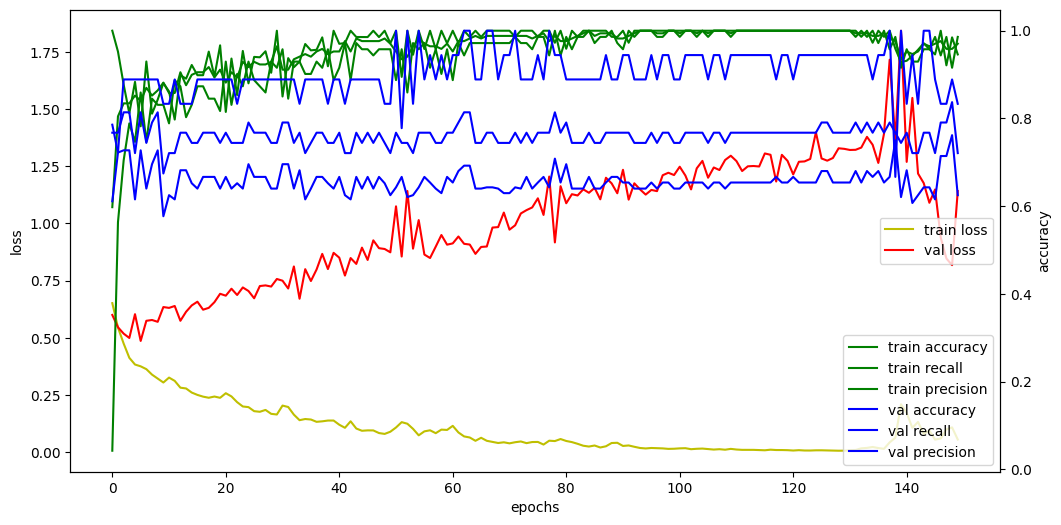

In [63]:
fig, loss_ax = plt.subplots(figsize=(12,6))
loss_ax.plot(hist.history['loss'], 'y', label='train loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train accuracy')
acc_ax.plot(hist.history['recall'], 'g', label='train recall')
acc_ax.plot(hist.history['precision'], 'g', label='train precision')

acc_ax.plot(hist.history['val_accuracy'], 'b', label='val accuracy')
acc_ax.plot(hist.history['val_recall'], 'b', label='val recall')
acc_ax.plot(hist.history['val_precision'], 'b', label='val precision')
loss_ax.set_xlabel('epochs')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(loc='center right')
acc_ax.legend()
plt.show()

In [65]:
score = model.evaluate(X_test, y_test, verbose=0)
print('model loss : ',score[0])
print('model accuracy : ',score[1])
print('model recall : ',score[2])
print('model prevision : ',score[3])

model loss :  1.5237157344818115
model accuracy :  0.8021978139877319
model recall :  0.7599999904632568
model prevision :  0.8636363744735718


In [67]:
#교차표
y_test.reshape(-1) #실제값

array([0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1,
       1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 1, 1], dtype=int64)

In [70]:
y_hat = (model.predict(X_test)>0.5).astype(int).reshape(-1)
pd.crosstab(y_test.reshape(-1), y_hat,
           rownames=['실제값'], colnames=['예측값'])

3/3 [==============================] - 0s 2ms/step


예측값,0,1
실제값,,
0,35,6
1,12,38


# 4. 모델 사용(저장, 예측)

In [74]:
from tensorflow.keras.models import save_model
model.save('data/07_heaer.h5')
save_model(model, 'data/07_heaer.h5')

In [79]:
from tensorflow.keras.models import load_model
model2 = load_model('data/07_heaer.h5')
model2.summary()

Model: "sequential_9"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_8 (Dense)             (None, 32)                448       
                                                                 
 dense_9 (Dense)             (None, 16)                528       
                                                                 
 dense_10 (Dense)            (None, 1)                 17        
                                                                 
Total params: 993
Trainable params: 993
Non-trainable params: 0
_________________________________________________________________


# 분류분석
1. 데이터 셋 생성 & 전처리
     엑셀 -> 데이터프레임 -> ?처리(df.replace('?',np.nan) -> 결측치 처리
     -> X, y 분리 -> X변수 스케일조정 -> train_test_split함수로 학습셋과 테스트셋분리
     -> y 변수들의 원핫인코딩
2. 모델 생성(입력13, 출력2) & 학습과정 설정 & 학습
3. 모델 평가(그래프, 평가, 교차표)
4. 모델 사용(저장, 예측)

## 1. 데이터 셋 생성 & 전처리

In [81]:
from tensorflow.keras.utils import to_categorical
Y_train = to_categorical(y_train)
Y_test = to_categorical(y_test)
Y_train.shape, Y_test.shape

((212, 2), (91, 2))

# 2. 모델 생성(입력13, 출력1) & 학습과정 설정 & 학습

In [82]:
from tensorflow.keras.layers import Dropout
model = Sequential()
model.add(Input(shape=(8,)))
model.add(Dense(units=32, activation='relu'))
model.add(Dropout(0.2)) #과적합을 해결
model.add(Dense(units=64, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(units=16, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(units=8, activation='relu'))
model.add(Dense(units=2, activation='softmax'))
model.summary()

Model: "sequential_10"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_11 (Dense)            (None, 32)                288       
                                                                 
 dropout (Dropout)           (None, 32)                0         
                                                                 
 dense_12 (Dense)            (None, 64)                2112      
                                                                 
 dropout_1 (Dropout)         (None, 64)                0         
                                                                 
 dense_13 (Dense)            (None, 16)                1040      
                                                                 
 dropout_2 (Dropout)         (None, 16)                0         
                                                                 
 dense_14 (Dense)            (None, 8)               

In [86]:
model.compile(loss='categorical_crossentropy',
             optimizer='nadam',
             metrics=['accuracy'])

# 3. 모델 평가

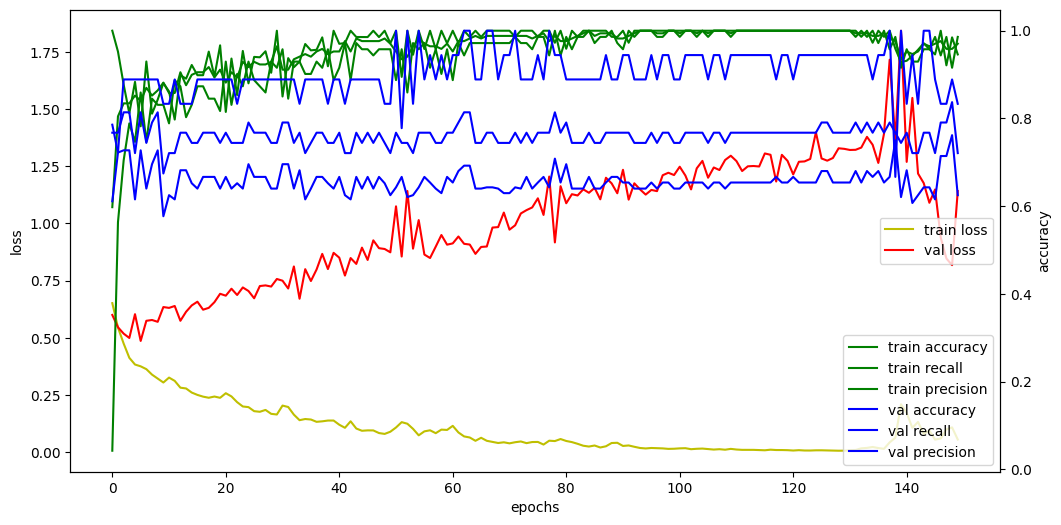

In [87]:
fig, loss_ax = plt.subplots(figsize=(12,6))
loss_ax.plot(hist.history['loss'], 'y', label='train loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train accuracy')
acc_ax.plot(hist.history['recall'], 'g', label='train recall')
acc_ax.plot(hist.history['precision'], 'g', label='train precision')

acc_ax.plot(hist.history['val_accuracy'], 'b', label='val accuracy')
acc_ax.plot(hist.history['val_recall'], 'b', label='val recall')
acc_ax.plot(hist.history['val_precision'], 'b', label='val precision')
loss_ax.set_xlabel('epochs')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(loc='center right')
acc_ax.legend()
plt.show()

In [91]:
hist = model.fit(X_train, Y_train,
                epochs=150,
                validation_data=(Y_train, Y_test),
                verbose=0)

ValueError: in user code:

    File "C:\Users\Admin\anaconda3\envs\ml-dl-nlp\lib\site-packages\keras\engine\training.py", line 1160, in train_function  *
        return step_function(self, iterator)
    File "C:\Users\Admin\anaconda3\envs\ml-dl-nlp\lib\site-packages\keras\engine\training.py", line 1146, in step_function  **
        outputs = model.distribute_strategy.run(run_step, args=(data,))
    File "C:\Users\Admin\anaconda3\envs\ml-dl-nlp\lib\site-packages\keras\engine\training.py", line 1135, in run_step  **
        outputs = model.train_step(data)
    File "C:\Users\Admin\anaconda3\envs\ml-dl-nlp\lib\site-packages\keras\engine\training.py", line 993, in train_step
        y_pred = self(x, training=True)
    File "C:\Users\Admin\anaconda3\envs\ml-dl-nlp\lib\site-packages\keras\utils\traceback_utils.py", line 70, in error_handler
        raise e.with_traceback(filtered_tb) from None
    File "C:\Users\Admin\anaconda3\envs\ml-dl-nlp\lib\site-packages\keras\engine\input_spec.py", li

In [88]:
score = model.evaluate(X_test,Y_test, verbose=0)
print('model loss : ',score[0])
print('model accuracy : ',score[1])
print('model recall : ',score[2])
print('model prevision : ',score[3])

ValueError: in user code:

    File "C:\Users\Admin\anaconda3\envs\ml-dl-nlp\lib\site-packages\keras\engine\training.py", line 1727, in test_function  *
        return step_function(self, iterator)
    File "C:\Users\Admin\anaconda3\envs\ml-dl-nlp\lib\site-packages\keras\engine\training.py", line 1713, in step_function  **
        outputs = model.distribute_strategy.run(run_step, args=(data,))
    File "C:\Users\Admin\anaconda3\envs\ml-dl-nlp\lib\site-packages\keras\engine\training.py", line 1701, in run_step  **
        outputs = model.test_step(data)
    File "C:\Users\Admin\anaconda3\envs\ml-dl-nlp\lib\site-packages\keras\engine\training.py", line 1665, in test_step
        y_pred = self(x, training=False)
    File "C:\Users\Admin\anaconda3\envs\ml-dl-nlp\lib\site-packages\keras\utils\traceback_utils.py", line 70, in error_handler
        raise e.with_traceback(filtered_tb) from None
    File "C:\Users\Admin\anaconda3\envs\ml-dl-nlp\lib\site-packages\keras\engine\input_spec.py", lin